# **Tugas Akhir IF5250 Deep Learning**

# **Audio-CRNN-Benchmarking-ESC-50**

||Identitas|
|--|--|
|Nama|Siti Ramadina Goethe K.|
|NIM|15322001|
|Kode Mahasiswa|MHS-06|
|Dataset|[ESC-50](https://github.com/karolpiczak/ESC-50)|
|||

# Persiapan Awal
## Install Dependencies

In [12]:
import os
import torch
import torch.nn as nn
import torchaudio
import torchaudio.functional as F
import torchaudio.transforms as T
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

print("Setup complete.")

Setup complete.


## Download dan Load Dataset ESC-50

In [9]:
# Unduh otomatis dari GitHub
if not os.path.exists('ESC-50-master'):
  !wget https://github.com/karoldvl/ESC-50/archive/master.zip
  !unzip -oq master.zip
  print("Selesai mengunduh dataset ESC-50 dari GitHub")
else:
  print("Dataset ESC-50 sudah tersedia.")


Dataset ESC-50 sudah tersedia.


In [10]:
# Baca data
csv_path = '/content/ESC-50-master/meta/esc50.csv'
wav_dir_path = '/content/ESC-50-master/audio'

df = pd.read_csv(csv_path)
print(f"Total data: {len(df)} sampel")
df.head()

Total data: 2000 sampel


,filename,fold,target,category,esc10,src_file,take
0,1-100032-A-0.wav,1,0,dog,True,100032,A
1,1-100038-A-14.wav,1,14,chirping_birds,False,100038,A
2,1-100210-A-36.wav,1,36,vacuum_cleaner,False,100210,A
3,1-100210-B-36.wav,1,36,vacuum_cleaner,False,100210,B
4,1-101296-A-19.wav,1,19,thunderstorm,False,101296,A


## Konversi File Audio ke Mel-Spectogram

In [11]:
# Konversi
mel_spectogram = T.MelSpectrogram(
    sample_rate = 22050,
    n_fft = 1024,
    hop_length = 512,
    n_mels = 64,
)

# Ubah audio ke Log-Mel-Spectogram
def log_mel_spec(path):
  waveform, sample_rate = torchaudio.load(path)
  mel_spec = mel_spectogram(waveform)
  log_mel = T.AmplitudeToDB(mel_spec, top_db=80)(mel_spec)
  return log_mel[0]


In [15]:
# Kelas ESC-50 Dataset
class ESC50Dataset(Dataset):
  def __init__(self, df, wav_dir, transform=None):
    self.df = df
    self.wav_dir = wav_dir
    self.transform = transform

  def __len__(self):
    return len(self.df)

  def __getitem__(self, idx):
    wav_name = self.df.iloc[idx]['filename']
    label = self.df.iloc[idx]['target']
    audio_path = os.path.join(self.wav_dir, wav_name)

    # Ambil mel-spec
    mel_spec = log_mel_spec(audio_path)
    mel_spec = mel_spec.unsqueeze(0) # tambah dimensi channel (1, freq, t)
    return mel_spec, label

dataset = ESC50Dataset(df, wav_dir_path)

Id: 1482 | Label: 0 | Kategori: dog
Ukuran Tensor Spectogram: torch.Size([1, 64, 431]) (Ch, Mel, t)


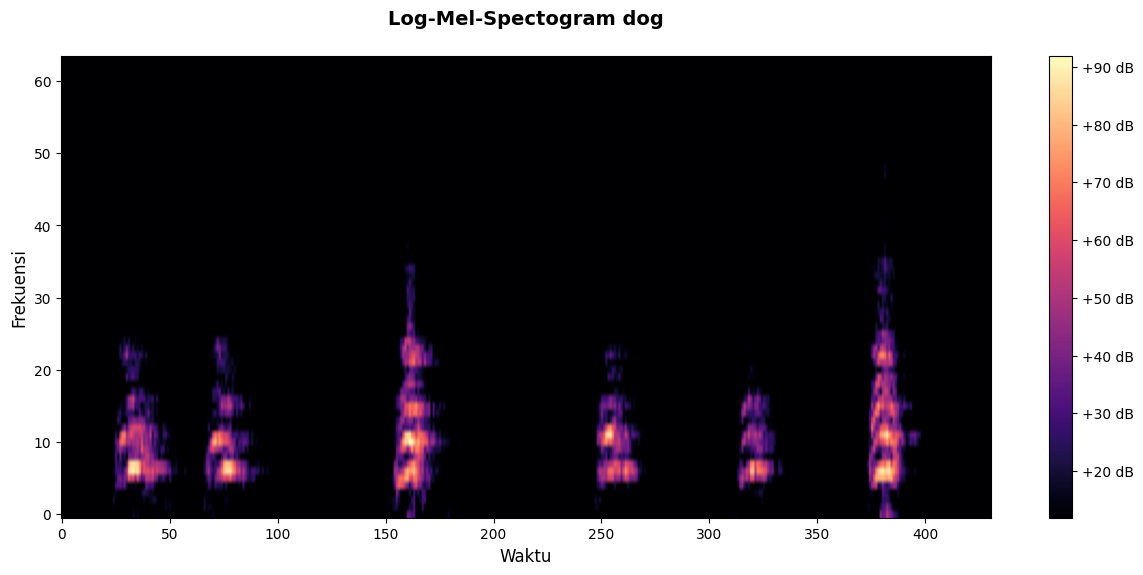

In [29]:
# Contoh representasi visual dari suara (spektorgram)

# Pilih satu sampel acak
idx = np.random.randint(0, len(dataset))
mel, label = dataset[idx]
category = df.iloc[idx]['category']

print(f"Id: {idx} | Label: {label} | Kategori: {category}")
print(f"Ukuran Tensor Spectogram: {mel.shape} (Ch, Mel, t)")

plt.figure(figsize=(15,6))
plt.imshow(mel[0].numpy(), origin='lower', aspect='auto', cmap='magma')
plt.title(f"Log-Mel-Spectogram {category}", fontsize=14, y=1.05, fontweight='bold')
plt.xlabel("Waktu", fontsize=12)
plt.ylabel("Frekuensi", fontsize=12)
plt.colorbar(format="%+2.0f dB") # tambah satuan pada bar
plt.show()
